# OpenCV Axis Detection - Separate Pipelines

Deze notebook behandelt **horizontal bar charts** en **vertical bar charts** als twee losse pipelines.

Dit is belangrijk omdat één afbeelding meerdere grafieken kan bevatten:
- sommige charts hebben horizontale bars;
- sommige charts hebben verticale bars;
- soms staan beide soorten in dezelfde afbeelding.

Daarom doen we dit niet meer:

```text
eerst kiezen: horizontal OF vertical
```

Maar dit:

```text
Pipeline A: horizontal bars detecteren → linker as vinden
Pipeline B: vertical bars detecteren → onderste x-as vinden
Daarna resultaten combineren
```

## Output kleuren

- Oranje boxen = gevonden horizontale bars
- Roze boxen = gevonden verticale bars
- Blauw = linker as voor horizontal bar charts
- Groen = onderste x-as voor vertical bar charts


In [ ]:
# Run once if packages are missing
%pip install opencv-python matplotlib numpy pandas

In [1]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("OpenCV version:", cv2.__version__)

OpenCV version: 4.13.0


## 1. Settings

Pas `IMAGE_PATH` aan naar jouw afbeelding.


In [2]:
IMAGE_PATH = Path("../Dataset/Compliant/7.png")

OUTPUT_DIR = Path("../output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Mask settings
DARK_THRESHOLD = 235
SATURATION_MAX = 190
BORDER_MARGIN_RATIO = 0.02

# Horizontal bar settings
MIN_HBAR_WIDTH = 20
MIN_HBAR_HEIGHT = 4
MAX_HBAR_HEIGHT = 45
MIN_HBAR_ASPECT = 1.6

# Vertical bar settings
MIN_VBAR_HEIGHT = 20
MIN_VBAR_WIDTH = 4
MAX_VBAR_WIDTH = 45
MIN_VBAR_ASPECT = 1.6

# Alignment settings
HORIZONTAL_AXIS_TOLERANCE_X = 12
VERTICAL_AXIS_TOLERANCE_Y = 12
MIN_BARS_ON_AXIS = 2

# Do not hide candidates during debugging
MIN_SCORE_TO_SHOW = 0
MAX_AXES_TO_DRAW = 30

## 2. Helper functions

In [6]:
def find_vertical_axes_from_horizontal_mask(horizontal_mask, min_supporting_bars=2):
    h, w = horizontal_mask.shape[:2]

    # 1. Zoek verticale lijnstukken in de horizontal bar mask
    vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 25))
    vertical_lines = cv2.morphologyEx(horizontal_mask, cv2.MORPH_OPEN, vertical_kernel)

    # 2. Zoek horizontale bar blobs
    contours, _ = cv2.findContours(horizontal_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    bars = []
    for cnt in contours:
        x, y, bw, bh = cv2.boundingRect(cnt)

        aspect = bw / max(bh, 1)

        # filter voor horizontale bars
        if bw > 25 and 4 <= bh <= 45 and aspect > 1.6:
            bars.append({
                "x": x,
                "y": y,
                "w": bw,
                "h": bh,
                "x_left": x,
                "x_right": x + bw,
                "y_top": y,
                "y_bottom": y + bh,
                "y_center": y + bh // 2
            })

    # 3. Zoek verticale lijn-contours
    line_contours, _ = cv2.findContours(vertical_lines, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    axes = []

    for cnt in line_contours:
        x, y, lw, lh = cv2.boundingRect(cnt)

        # lijn moet verticaal genoeg zijn
        if lh < 30 or lw > 8:
            continue

        x_axis = x + lw // 2

        supporting_bars = []

        for bar in bars:
            # bar moet ongeveer rechts starten bij deze verticale lijn
            starts_near_line = abs(bar["x_left"] - x_axis) <= 8

            # bar moet overlappen met de hoogte van de lijn
            overlaps_y = not (
                bar["y_bottom"] < y or
                bar["y_top"] > y + lh
            )

            if starts_near_line and overlaps_y:
                supporting_bars.append(bar)

        if len(supporting_bars) >= min_supporting_bars:
            y1 = min(bar["y_top"] for bar in supporting_bars)
            y2 = max(bar["y_bottom"] for bar in supporting_bars)

            axes.append({
                "x1": x_axis,
                "y1": y1,
                "x2": x_axis,
                "y2": y2,
                "supporting_bars": len(supporting_bars)
            })

    return axes, bars, vertical_lines

## 3. Run separate pipelines

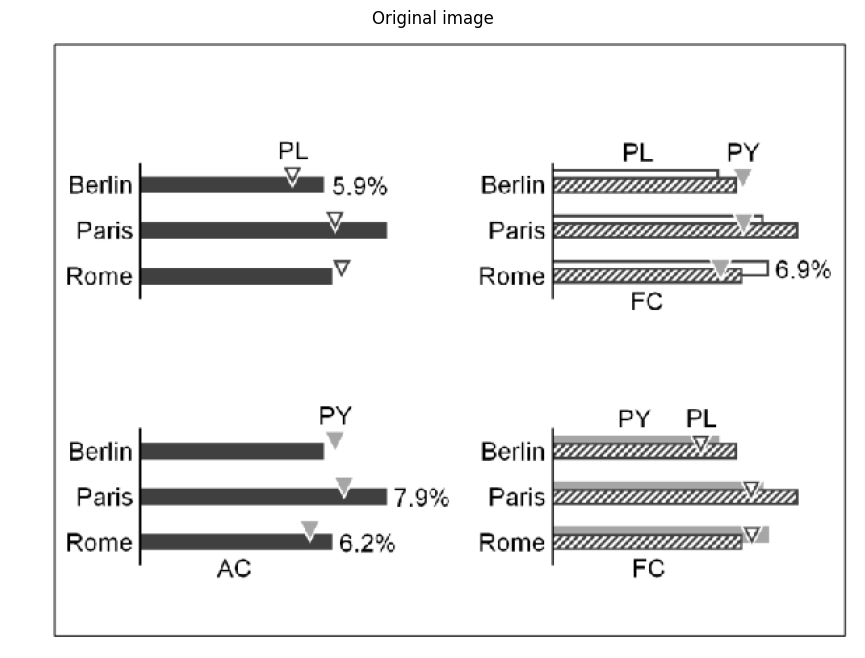

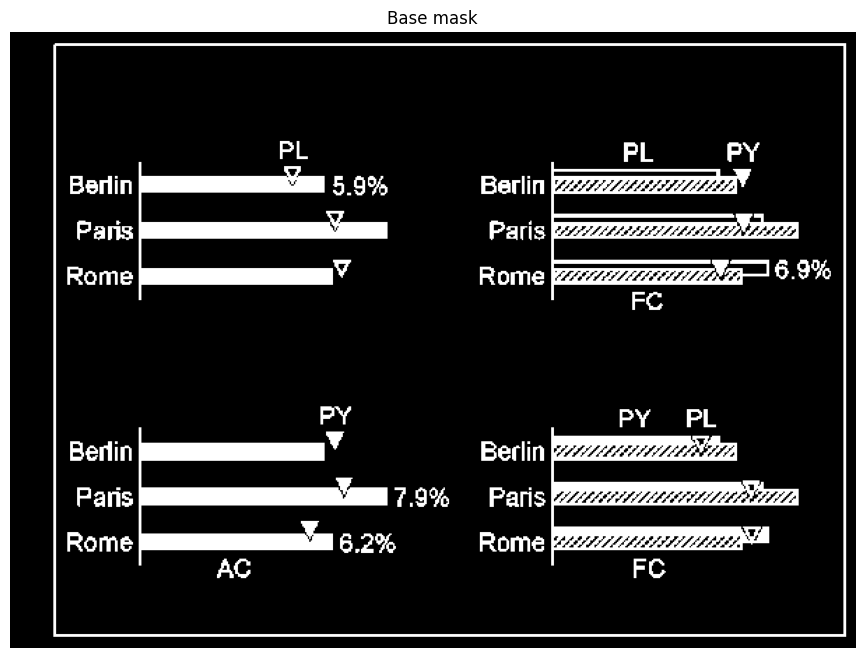

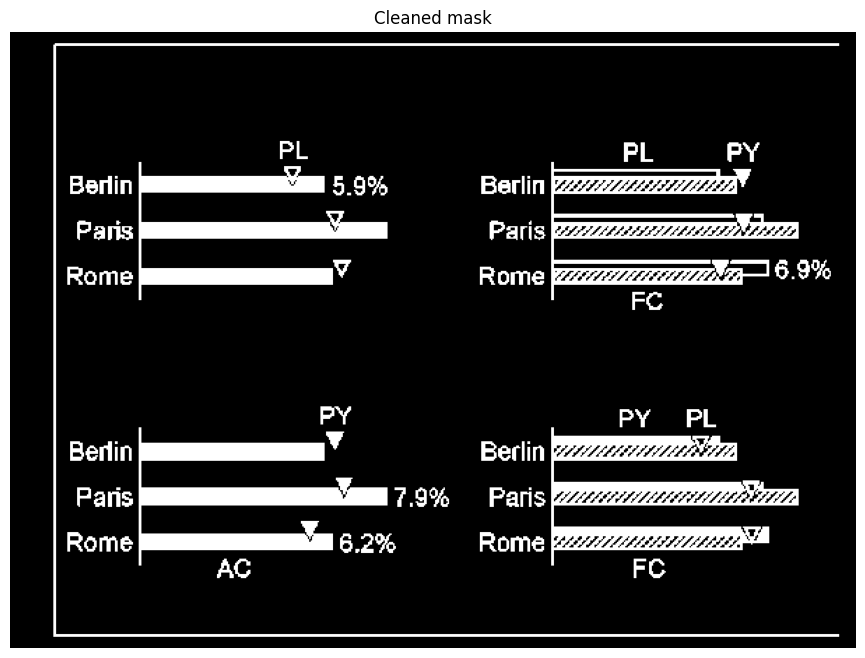

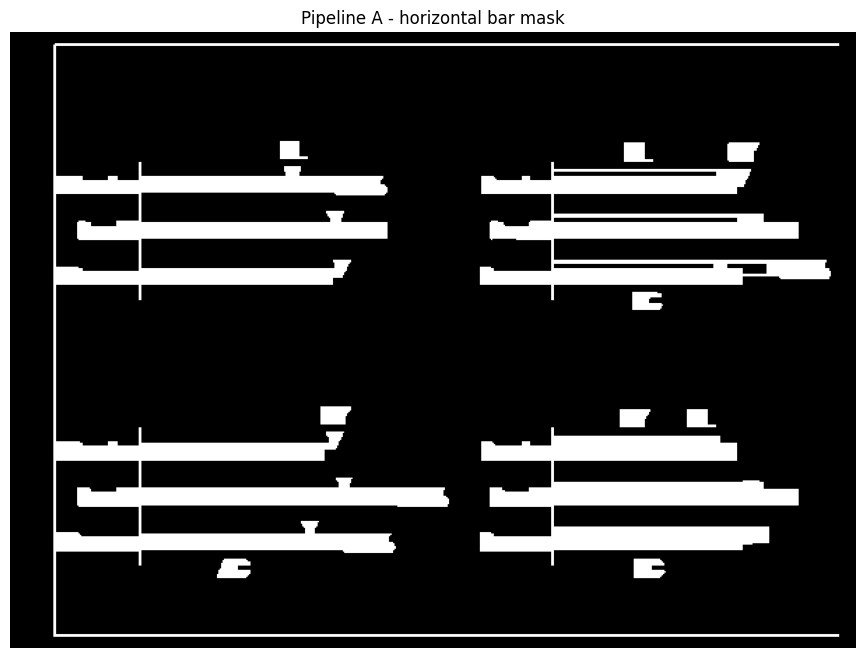

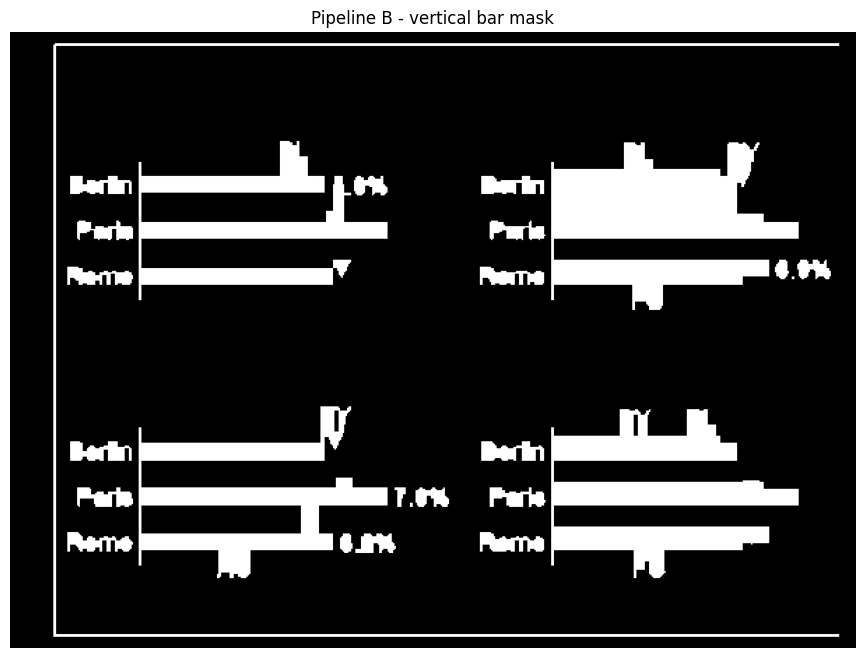

Horizontal bars found: 7
Vertical bars found: 0
Left axes found: 1
Bottom x-axes found: 0
Total axes found: 1


In [7]:
image = load_image(IMAGE_PATH)
show_image("Original image", image)

result = run_separate_pipelines(image)

show_image("Base mask", result["base_mask"])
show_image("Cleaned mask", result["cleaned_mask"])

show_image("Pipeline A - horizontal bar mask", result["horizontal_mask"])
show_image("Pipeline B - vertical bar mask", result["vertical_mask"])

print("Horizontal bars found:", len(result["horizontal_bars"]))
print("Vertical bars found:", len(result["vertical_bars"]))
print("Left axes found:", len(result["left_axes"]))
print("Bottom x-axes found:", len(result["bottom_axes"]))
print("Total axes found:", len(result["axes"]))

## 4. Show final result

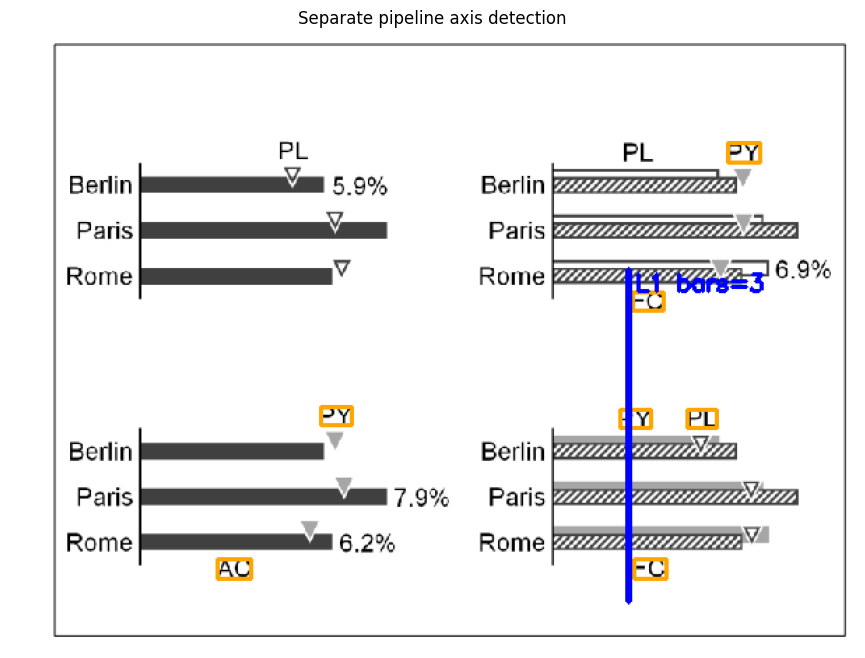

Saved to: ..\output\7_separate_pipeline_axes.png


In [8]:
output = draw_result(image, result, max_axes=MAX_AXES_TO_DRAW)
show_image("Separate pipeline axis detection", output)

output_path = OUTPUT_DIR / f"{IMAGE_PATH.stem}_separate_pipeline_axes.png"
cv2.imwrite(str(output_path), output)
print("Saved to:", output_path)

## 5. Debug tables

In [ ]:
print("Horizontal bars:")
display(bars_to_dataframe(result["horizontal_bars"]).head(30))

print("Vertical bars:")
display(bars_to_dataframe(result["vertical_bars"]).head(30))

print("Axes:")
display(axes_to_dataframe(result["axes"]))

## 6. Batch test all images

In [ ]:
DATASET_DIR = Path("../Dataset")
BATCH_OUTPUT_DIR = OUTPUT_DIR / "separate_pipeline_axis_detection"
BATCH_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

image_extensions = [".png", ".jpg", ".jpeg", ".webp"]
image_paths = []

for ext in image_extensions:
    image_paths.extend(DATASET_DIR.rglob(f"*{ext}"))

print("Found images:", len(image_paths))

summary_rows = []

for path in image_paths:
    try:
        img = load_image(path)
        res = run_separate_pipelines(img)
        out = draw_result(img, res, max_axes=MAX_AXES_TO_DRAW)

        relative = path.relative_to(DATASET_DIR)
        save_path = BATCH_OUTPUT_DIR / relative
        save_path.parent.mkdir(parents=True, exist_ok=True)

        cv2.imwrite(str(save_path), out)

        summary_rows.append({
            "image": str(relative),
            "horizontal_bars": len(res["horizontal_bars"]),
            "vertical_bars": len(res["vertical_bars"]),
            "left_axes": len(res["left_axes"]),
            "bottom_axes": len(res["bottom_axes"]),
            "total_axes": len(res["axes"]),
            "output": str(save_path)
        })

        print("Saved:", save_path)

    except Exception as e:
        print("Error with", path, ":", e)

summary_df = pd.DataFrame(summary_rows)
summary_df

## 7. Explanation for your assignment

You can use this text:

> This notebook uses two separate OpenCV pipelines because one image can contain both horizontal and vertical bar charts. The first pipeline detects horizontal bars and searches for a vertical left-side axis where multiple bars start at the same x-position. The second pipeline detects vertical bars and searches for a horizontal bottom x-axis where multiple bars end at the same y-position. The two pipelines are processed independently and their axis candidates are combined afterwards. This prevents the vertical bar mask from interfering with horizontal bar chart detection and makes the method more suitable for images that contain multiple chart types.
